# TITANIC SURVIVAL

this project is analyze the classic titanic data from kaggle

## Import the Library

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Renitia\\OneDrive\\Desktop\\Porto\\Portfolio\\data\\Titanic_train.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## About Dataset

 The Titanic_train.csv file includes a target column called Survived
 - a passenger survived (1) 
 - did not survive (0)

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


 The Titanic_train.csv file includes detailed information for 891 passengers 

In [98]:
df["Cabin"].isnull().sum()

np.int64(687)

In [99]:
df["Age"].isnull().sum()

np.int64(177)

In [100]:
df["Embarked"].isnull().sum()

np.int64(2)

 ## Missing Value Analysis

 there are 3 column with missing value:
 - Age (177)
 - Cabin (687)
 - Embarked (2), this easily could be ignore because it has only 2 missing.

 ### 1. Age (687)


In [101]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


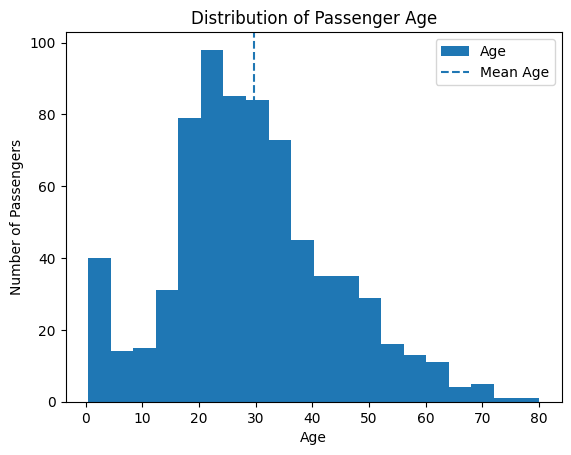

In [102]:
df["Age"].plot(kind="hist", bins=20)

plt.axvline(
    df["Age"].mean(),
    linestyle="--",
    label="Mean Age"
)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()

plt.show()

### Insight

Most passengers were concentrated between 20 and 40 years old.

The age distribution is slightly right-skewed, with fewer passengers at older ages.

### 2. Cabin Missing (687)

In [103]:
df["Cabin_missing"] = df["Cabin"].isnull()

pd.crosstab(
    df["Pclass"],
    df["Cabin_missing"],
    normalize="index"
) * 100

Cabin_missing,False,True
Pclass,,
1,81.481481,18.518519
2,8.695652,91.304348
3,2.443992,97.556008


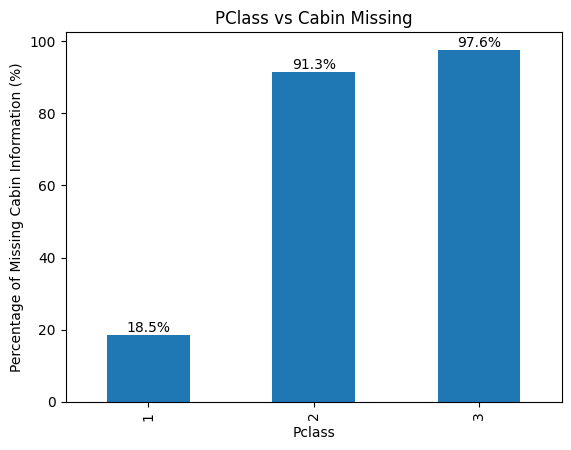

In [104]:
Pclass_vs_Cabin_Missing = (
    df.groupby("Pclass")["Cabin_missing"]
    .mean() * 100
)

ax = Pclass_vs_Cabin_Missing.plot(kind="bar")
plt.title("PClass vs Cabin Missing")
plt.ylabel("Percentage of Missing Cabin Information (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

### Insight

Missing cabin values are disproportionately concentrated among  second and third-class passengers, suggesting that the missingness is related to passenger class rather than occurring completely at random.

## Missing Value Handling

The dataset contains missing values in Age, Cabin, and Embarked.

- Missing Embarked values were filled using the mode because only two records were missing.
- Missing Age values were filled using the median age to reduce the impact of outliers.
- Cabin contained more than 77% missing values. A binary indicator (Cabin_missing) was created to preserve potential information before dropping the original column.


In [105]:
# Embarked
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

# Age
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

# Cabin indicator
df["Cabin_missing"] = df["Cabin"].isnull()

# Drop cabin
df = df.drop("Cabin", axis=1)

## Exploratory Data Analysis (EDA)

### 1. Survival by Gender

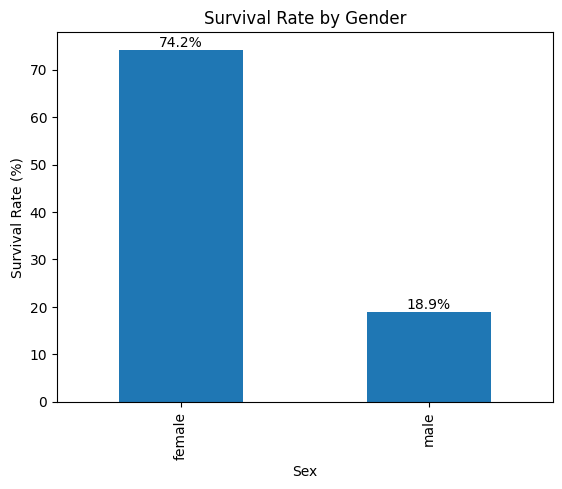

In [106]:
survival_by_gender = (
    df.groupby("Sex")["Survived"]
    .mean() * 100
)

ax = survival_by_gender.plot(kind="bar")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

### Insight

Female passengers had a survival rate of approximately 74%, while male passengers had a survival rate below 20%.

This suggests that gender was one of the strongest factors associated with survival.

## 2. Survival by Passenger Class

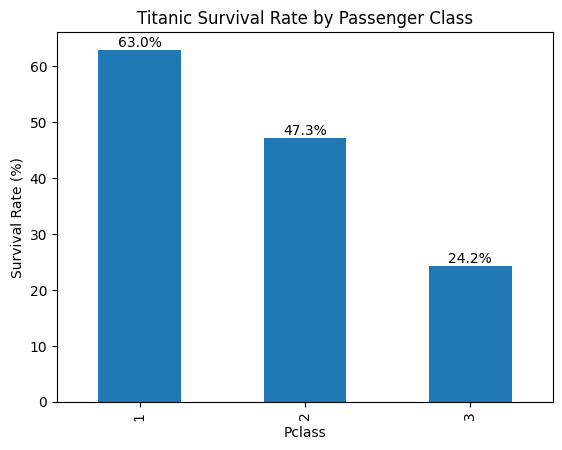

In [107]:
survival_by_class = (
    df.groupby("Pclass")["Survived"]
    .mean() * 100
)

ax = survival_by_class.plot(kind="bar")

plt.title("Titanic Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)")
for container in ax.containers: 
    ax.bar_label(container, fmt='%.1f%%')
plt.show()

### Insight

First-class passengers had the highest survival rate (approximately 63%), followed by second-class and third-class passengers.

This indicates that passenger class was an important factor associated with survival, with higher-class passengers having a greater chance of survival.

Although cabin information contains a large number of missing values, the survival rate by passenger class remains a reliable finding because the analysis is based on the Pclass variable rather than the Cabin variable.

## 3. Survival by Age


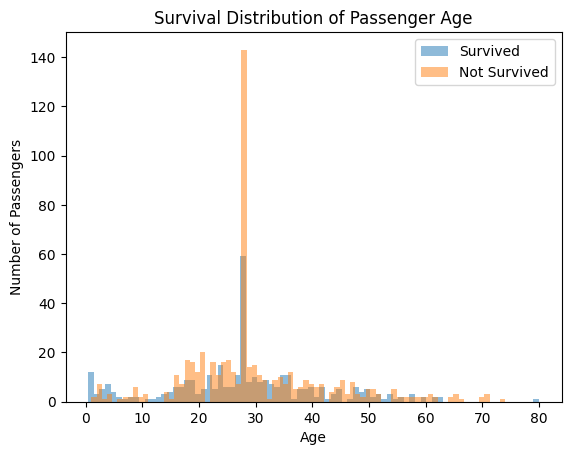

In [108]:
df[df["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=80,
    alpha=0.5,
    label="Survived"
)

df[df["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=80,
    alpha=0.5,
    label="Not Survived"
)

plt.title("Survival Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

### Insight

the passenger age bellow 10 has a higher survival chance, the older passenger more likely to not survived

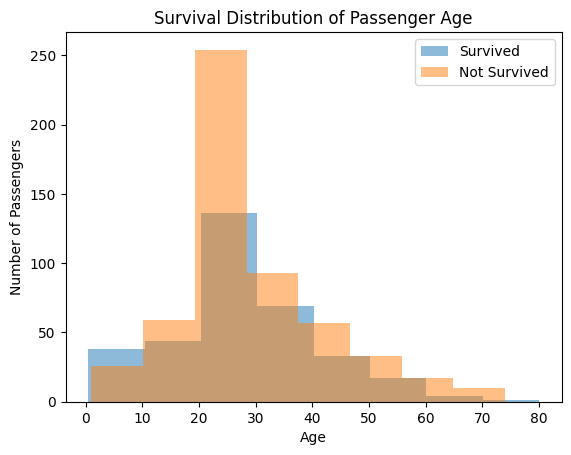

In [109]:
df[df["Survived"] == 1]["Age"].plot(
    kind="hist",
    bins=8,    alpha=0.5,
    label="Survived"
)

df[df["Survived"] == 0]["Age"].plot(
    kind="hist",
    bins=8,
    alpha=0.5,
    label="Not Survived"
)

plt.title("Survival Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

### Insight

Passengers under 10 years old showed a higher likelihood of survival compared to other age groups.

This suggests that children may have received priority during the evacuation process.

### Interpretation

First-class passengers had a substantially higher survival rate than passengers in lower classes.

One possible explanation is that first-class passengers may have had better access to lifeboats due to their location on the ship and their proximity to evacuation routes. However, the dataset does not contain information about passenger locations or the evacuation process, so this explanation cannot be confirmed directly from the available data.

Female passengers had a significantly higher survival rate than male passengers.

This pattern may be related to evacuation practices during the disaster, where women and children were often prioritized for lifeboat access. However, the dataset does not contain direct information about the evacuation process, so this interpretation should be considered a hypothesis rather than a confirmed conclusion.



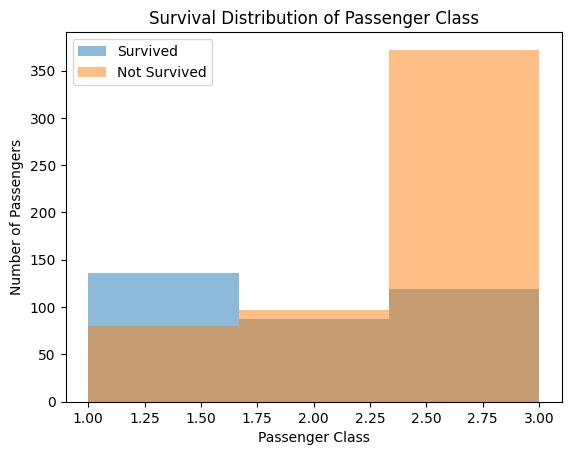

In [110]:
df[df["Survived"] == 1]["Pclass"].plot(
    kind="hist",
    bins=3,
    alpha=0.5,
    label="Survived"
)

df[df["Survived"] == 0]["Pclass"].plot(
    kind="hist",
    bins=3,
    alpha=0.5,
    label="Not Survived"
)

plt.title("Survival Distribution of Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend()
plt.show()

## 4. Survival by Embarked

In [111]:
df["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

### Insight

The majority of passengers embarked from Southampton, while substantially fewer passengers boarded from Cherbourg and Queenstown.


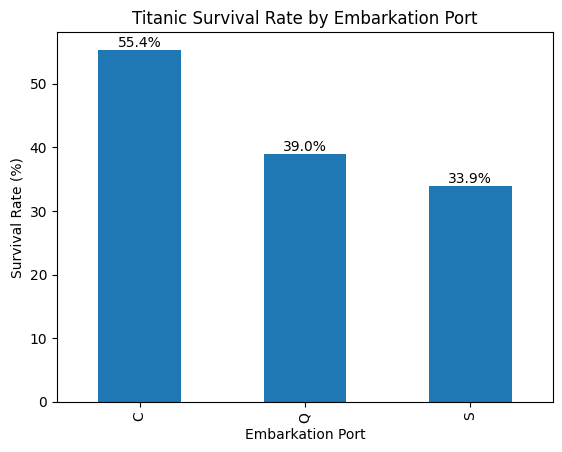

In [112]:
survival_by_embarked = (
    df.groupby("Embarked")["Survived"]
    .mean() * 100
)

ax = survival_by_embarked.plot(kind="bar")

plt.title("Titanic Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight

Passengers who embarked from Cherbourg showed the highest survival rate among the three embarkation ports.

In [113]:
pd.crosstab(
    df["Embarked"],
    df["Pclass"],
    normalize="index"
) * 100

Pclass,1,2,3
Embarked,,,
C,50.595238,10.119048,39.285714
Q,2.597403,3.896104,93.506494
S,19.969040,25.386997,54.643963


### Insight

more that 50% Passenger from Cherbourg in the first-class, this maybe related to highest survival rate

## 5. Survival by Family Size

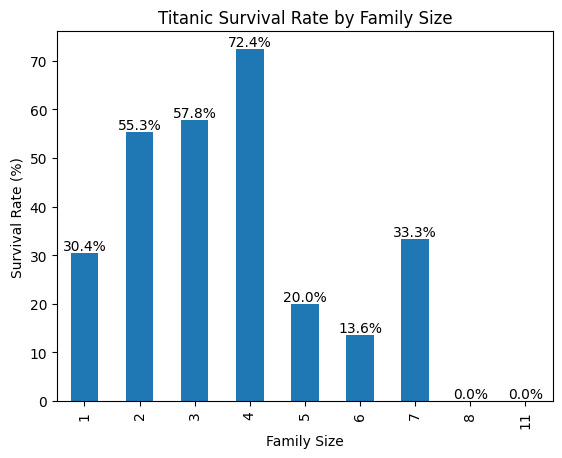

In [116]:
df["family_size"] = df["SibSp"] + df["Parch"] + 1

survival_by_familysize = (
    df.groupby("family_size")["Survived"]
    .mean() * 100
)

ax = survival_by_familysize.plot(kind="bar")

plt.title("Titanic Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.show()

### Insight

Passengers traveling in families of four had the highest survival rate, at approximately 72.4%.

This suggests that moderate-sized family groups may have had better survival outcomes compared to passengers traveling alone or in very large families.

In [118]:
df["family_size"].value_counts()

family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

### Insight

Family groups of four showed the highest survival rate (72.4%). However, the group contained only 29 passengers, making it difficult to draw a strong conclusion from this observation alone.

## Key Findings

1. Female passengers had a significantly higher survival rate than male passengers, suggesting that gender was one of the strongest factors associated with survival.

2. First-class passengers were substantially more likely to survive than second- and third-class passengers. This may be related to differences in access to evacuation routes and lifeboats.

3. Children under the age of 10 showed a higher likelihood of survival compared to other age groups, which may reflect evacuation priorities during the disaster.

4. More than 77% of cabin records were missing. Further analysis showed that missing cabin information was strongly associated with passenger class, indicating that the missing values were not completely random.

5. Most passengers embarked from Southampton, making it the primary departure port represented in the dataset.

6. Family groups of four showed the highest observed survival rate (72.4%). However, this group consisted of only 29 passengers, so the result should be interpreted with caution.
